# Notebook 12 - t-SNE patient maps (feature space and SHAP space)

We project patients into 2D to look for structure. Two views:
feature-space t-SNE (do readmitted vs not separate in the raw data) and SHAP-space t-SNE
(do patients group by the reasons the model flags them).

t-SNE preserves local neighbourhoods only; distances between clusters and cluster sizes
are not meaningful. We read these as exploratory maps, not quantitative results.


## 1. Setup


In [2]:
# install and import libraries

!pip install shap -q
import os, pickle, time, warnings
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE

warnings.filterwarnings('ignore')

In [3]:
# parameters, file paths, and load the model, feature list, encoders, and split

RANDOM_STATE=42; N_SAMPLE=3000; PERPLEXITY=30

MROOT=''
CSV='bq-results-20260323-203006-1774297820102.csv'
OUT='NB12_outputs/'; os.makedirs(OUT, exist_ok=True)

feature_cols=pickle.load(open('final_feature_cols.pkl','rb'))
le_mappings =pickle.load(open('final_le_mappings.pkl','rb'))
split=pickle.load(open('final_split_indices.pkl','rb'))
model=pickle.load(open('xgboost_final_45f.pkl','rb'))

print(len(feature_cols),'features')

45 features


## 2. Data and test sample


In [4]:
# load data, fill missing values, encode categoricals, and take a test-set sample

df=pd.read_csv(CSV)
for c in ['marital_status','language','insurance','admission_location','discharge_location','race']: df[c]=df[c].fillna('UNKNOWN')
for c in ['num_lab_tests_24h','num_abnormal_labs','hemoglobin_min','wbc_max','creatinine_max','sodium_min','sodium_max','potassium_min','potassium_max','glucose_min','glucose_max']: df[c]=df[c].fillna(df[c].median())
for c in ['days_since_last_discharge','num_admissions_last_30d','num_admissions_last_90d','num_admissions_last_year','total_prior_admissions','recent_admission_flag','frequent_flyer_flag']: df[c]=df[c].fillna(0)

df=df.fillna(df.median(numeric_only=True))

cat=['gender','race','marital_status','language','insurance','admission_location','discharge_location','admission_type']

for c in cat:
    mapping=dict(le_mappings[c]['label_to_int'])
    mapped=df[c].astype(str).map(mapping)
    if mapped.isna().any():
        fb=mapping.get('UNKNOWN', pd.Series(mapped.dropna()).mode().iloc[0])
        mapped=mapped.fillna(fb)
    df[c]=mapped.astype(int)

df['admittime']=pd.to_datetime(df['admittime'])
ds=df.sort_values('admittime').reset_index(drop=True)

X_test=ds[feature_cols].iloc[split['val_end']:]; y_test=ds['readmitted_30d'].iloc[split['val_end']:]
samp=X_test.sample(N_SAMPLE, random_state=RANDOM_STATE); ysamp=y_test.loc[samp.index].values
p_samp=model.predict_proba(samp)[:,1]
print('sample:', samp.shape, '| readmit rate:', round(float(ysamp.mean()),3))

sample: (3000, 45) | readmit rate: 0.171


## 3. Feature-space t-SNE


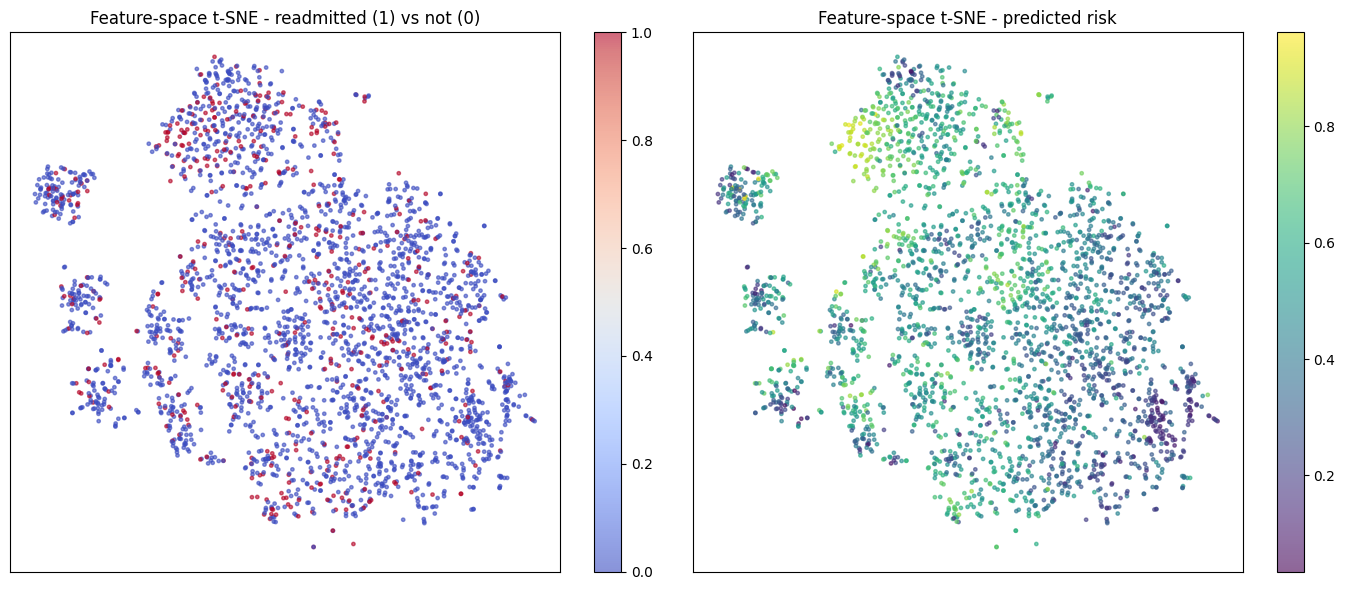

In [5]:
# feature-space t-SNE, coloured by readmission and by predicted risk

Xs=StandardScaler().fit_transform(samp.values)
emb_f=TSNE(n_components=2, perplexity=PERPLEXITY, init='pca', random_state=RANDOM_STATE).fit_transform(Xs)
np.save(OUT+'tsne_feature.npy', emb_f)

fig,ax=plt.subplots(1,2,figsize=(14,6))

for a,(col,lab,cmap) in zip(ax, [(ysamp,'readmitted (1) vs not (0)','coolwarm'),(p_samp,'predicted risk','viridis')]):
    sc=a.scatter(emb_f[:,0], emb_f[:,1], c=col, cmap=cmap, s=6, alpha=0.6)
    a.set_title('Feature-space t-SNE - '+lab); a.set_xticks([]); a.set_yticks([]); plt.colorbar(sc,ax=a)

plt.tight_layout(); plt.savefig(OUT+'tsne_feature.png', dpi=150, bbox_inches='tight'); plt.show()

## 4. SHAP-space t-SNE


In [6]:
# compute SHAP values for the sampled patients

import shap

bg=shap.sample(ds[feature_cols].iloc[:split['train_end']], 100, random_state=RANDOM_STATE)
sv=np.array(shap.TreeExplainer(model, data=bg, feature_perturbation='interventional').shap_values(samp, check_additivity=False))
np.save(OUT+'shap_values.npy', sv)

print('SHAP values:', sv.shape)

100%|===================| 2990/3000 [00:43<00:00]       

SHAP values: (3000, 45)


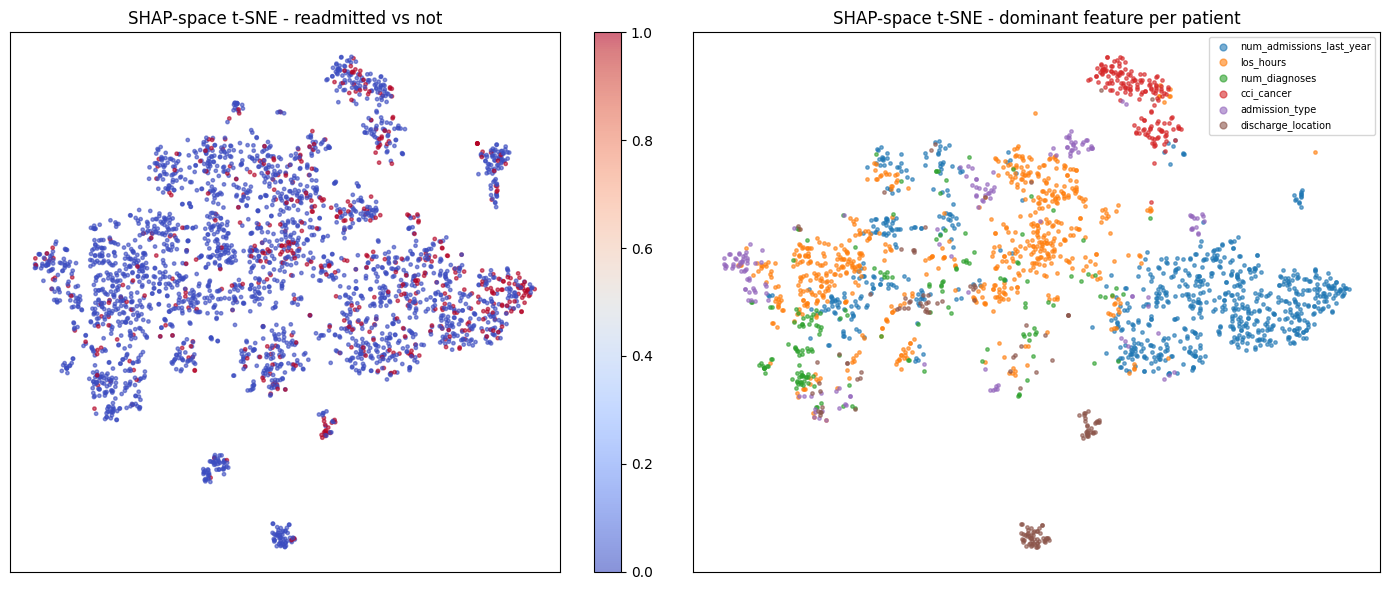

In [7]:
# SHAP-space t-SNE, coloured by readmission and by each patient's dominant feature

emb_s=TSNE(n_components=2, perplexity=PERPLEXITY, init='pca', random_state=RANDOM_STATE).fit_transform(sv)
np.save(OUT+'tsne_shap.npy', emb_s)

# colour by the feature with the largest |SHAP| for each patient (their dominant reason)
dom=np.argmax(np.abs(sv), axis=1)
top=pd.Series(dom).value_counts().head(6).index.tolist()
fig,ax=plt.subplots(1,2,figsize=(14,6))
sc0=ax[0].scatter(emb_s[:,0], emb_s[:,1], c=ysamp, cmap='coolwarm', s=6, alpha=0.6)
ax[0].set_title('SHAP-space t-SNE - readmitted vs not'); ax[0].set_xticks([]); ax[0].set_yticks([]); plt.colorbar(sc0,ax=ax[0])

for fi in top:
    m=dom==fi; ax[1].scatter(emb_s[m,0], emb_s[m,1], s=6, alpha=0.6, label=feature_cols[fi])

ax[1].set_title('SHAP-space t-SNE - dominant feature per patient'); ax[1].set_xticks([]); ax[1].set_yticks([]); ax[1].legend(fontsize=7, markerscale=2)
plt.tight_layout(); plt.savefig(OUT+'tsne_shap.png', dpi=150, bbox_inches='tight'); plt.show()

## 5. Summary
